In [1]:
from google.colab import files
uploaded = files.upload()  # select data.zip

Saving data.zip to data.zip


In [2]:
import zipfile

with zipfile.ZipFile("data.zip", "r") as zip_ref:
    zip_ref.extractall("data")

print("✅ Unzipped successfully")

✅ Unzipped successfully


In [3]:
import os

DATA_PATH = "data/data"
actions = ['hello','thanks','yes','no','stop',
           'peace','ok','fist','call','point']

print("📊 Dataset Balance Check:")
print("-" * 40)
counts = []
for action in actions:
    path = os.path.join(DATA_PATH, action)
    count = len(os.listdir(path))
    counts.append(count)
    bar = "█" * count
    print(f"  {action:<10} {count:>3} sequences  {bar}")

print("-" * 40)
print(f"  TOTAL    : {sum(counts)}")
print(f"  MIN      : {min(counts)} → {'⚠️ Collect more!' if min(counts) < 50 else '✅ OK'}")
print(f"  MAX      : {max(counts)}")
print(f"  IMBALANCE: {max(counts)/min(counts):.1f}x {'⚠️ Imbalanced!' if max(counts)/min(counts) > 1.5 else '✅ Balanced'}")

📊 Dataset Balance Check:
----------------------------------------
  hello       20 sequences  ████████████████████
  thanks      20 sequences  ████████████████████
  yes         20 sequences  ████████████████████
  no          20 sequences  ████████████████████
  stop        20 sequences  ████████████████████
  peace       20 sequences  ████████████████████
  ok          20 sequences  ████████████████████
  fist        20 sequences  ████████████████████
  call        20 sequences  ████████████████████
  point       20 sequences  ████████████████████
----------------------------------------
  TOTAL    : 200
  MIN      : 20 → ⚠️ Collect more!
  MAX      : 20
  IMBALANCE: 1.0x ✅ Balanced


In [4]:
import numpy as np
import os
import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                      BatchNormalization, Bidirectional)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All imports done")
print(f"TF version: {tf.__version__}")

✅ All imports done
TF version: 2.19.0


In [5]:
DATA_PATH = "data/data"
actions = ['hello','thanks','yes','no','stop',
           'peace','ok','fist','call','point']
SEQUENCE_LENGTH = 30
label_map = {label: num for num, label in enumerate(actions)}

sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    for sequence in sorted(os.listdir(action_path)):
        seq_path = os.path.join(action_path, sequence)
        window = []
        valid = True
        for frame_num in range(SEQUENCE_LENGTH):
            frame_path = os.path.join(seq_path, f"{frame_num}.npy")
            if not os.path.exists(frame_path):
                valid = False
                break
            res = np.load(frame_path)
            window.append(res)
        if valid:
            sequences.append(window)
            labels.append(label_map[action])

X = np.array(sequences, dtype=np.float32)
y = to_categorical(labels).astype(int)

print(f"✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")
print(f"✅ Loaded {len(sequences)} sequences across {len(actions)} actions")

✅ X shape: (200, 30, 63)
✅ y shape: (200, 10)
✅ Loaded 200 sequences across 10 actions


In [6]:
n_samples, n_frames, n_features = X.shape

# Normalize
X_flat = X.reshape(-1, n_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)
X = X_scaled.reshape(n_samples, n_frames, n_features)

# ✅ Save scaler — MUST use in predict.py too
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Data normalized")
print("✅ Scaler saved as scaler.pkl")

# Stratified split — ensures each class is equally represented in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

print(f"✅ Train: {X_train.shape}")
print(f"✅ Test : {X_test.shape}")

✅ Data normalized
✅ Scaler saved as scaler.pkl
✅ Train: (160, 30, 63)
✅ Test : (40, 30, 63)


In [7]:
def augment_sequence(seq):
    seq = seq.copy()

    # 1. Gaussian noise — simulates shaky hands
    seq += np.random.normal(0, 0.02, seq.shape)

    # 2. Random scale — simulates different distances from camera
    scale = np.random.uniform(0.88, 1.12)
    seq *= scale

    # 3. Time warp — simulates fast/slow gestures
    if np.random.rand() > 0.5:
        drop_idx = np.random.randint(1, len(seq) - 1)
        seq = np.delete(seq, drop_idx, axis=0)
        seq = np.vstack([seq, seq[-1]])  # pad last frame

    # 4. Mirror hand — simulates left/right hand variation
    if np.random.rand() > 0.5:
        seq[:, 0::3] = 1.0 - seq[:, 0::3]  # flip x coordinates

    return seq

np.random.seed(42)
X_aug, y_aug = list(X_train), list(y_train)

for i in range(len(X_train)):
    for _ in range(3):  # 3 augmented copies per original
        X_aug.append(augment_sequence(X_train[i]))
        y_aug.append(y_train[i])

X_train = np.array(X_aug, dtype=np.float32)
y_train = np.array(y_aug)

# Shuffle
shuffle_idx = np.random.permutation(len(X_train))
X_train = X_train[shuffle_idx]
y_train = y_train[shuffle_idx]

print(f"✅ Augmented train set: {X_train.shape}  (4x original)")

✅ Augmented train set: (640, 30, 63)  (4x original)


In [8]:
tf.random.set_seed(42)

model = Sequential([
    # Layer 1: Bidirectional LSTM — learns forward + backward gesture flow
    Bidirectional(LSTM(128, return_sequences=True),
                  input_shape=(SEQUENCE_LENGTH, n_features)),
    BatchNormalization(),
    Dropout(0.3),

    # Layer 2: Bidirectional LSTM — refines temporal patterns
    Bidirectional(LSTM(64, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.3),

    # Layer 3: Final LSTM — collapses sequence to single vector
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),

    # Dense head
    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(len(actions), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f"\n✅ Total parameters: {model.count_params():,}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       196,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 30, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,386 (1.64 MB)

 Trainable params: 428,490 (1.63 MB)

 Non-trainable params: 896 (3.50 KB)


✅ Total parameters: 429,386


In [9]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    )
]

print("✅ Callbacks ready")

✅ Callbacks ready


In [10]:
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

print("\n✅ TRAINING COMPLETE")
print(f"   Stopped at epoch: {len(history.history['accuracy'])}")
print(f"   Best val accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.1803 - loss: 2.4476
Epoch 1: val_accuracy improved from None to 0.60000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 284ms/step - accuracy: 0.2547 - loss: 2.2155 - val_accuracy: 0.6000 - val_loss: 2.1241 - learning_rate: 0.0010
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.4601 - loss: 1.5963
Epoch 2: val_accuracy improved from 0.60000 to 0.70000, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 323ms/step - accuracy: 0.5000 - loss: 1.4732 - val_accuracy: 0.7000 - val_loss: 1.7962 - learning_rate: 0.0010
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.6579 - loss: 1.1453
Epoch 3: val_accuracy improved from 0.70000 to 0.75000, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/

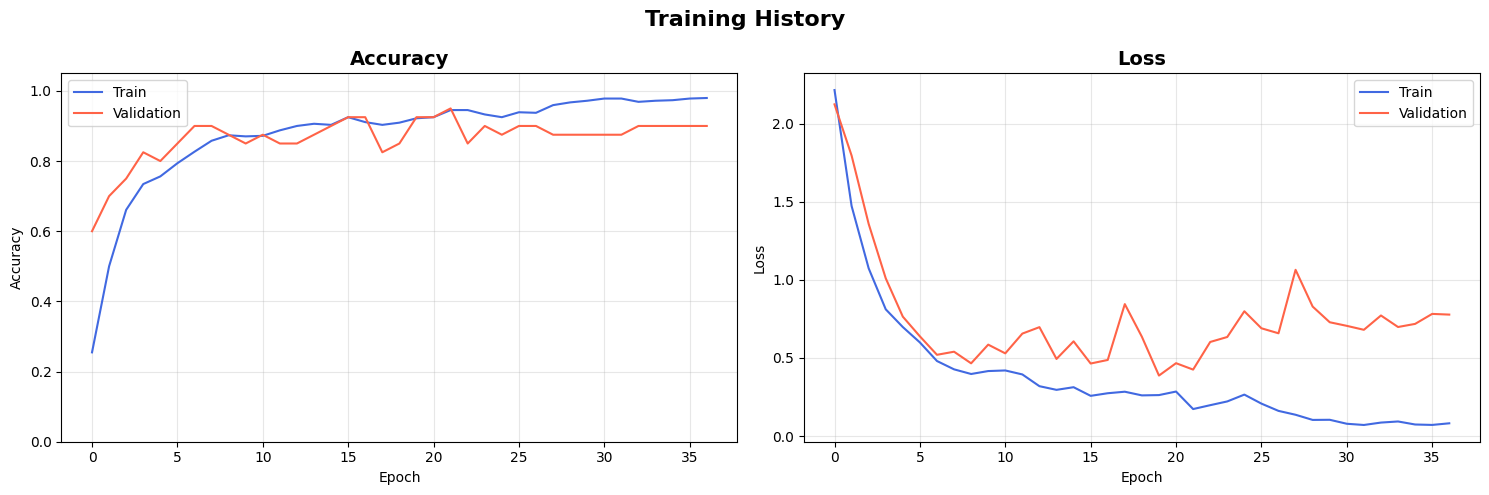

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='tomato')
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Loss
axes[1].plot(history.history['loss'], label='Train', color='royalblue')
axes[1].plot(history.history['val_loss'], label='Validation', color='tomato')
axes[1].set_title('Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

✅ Test Accuracy : 95.00%
✅ Test Loss     : 0.4254


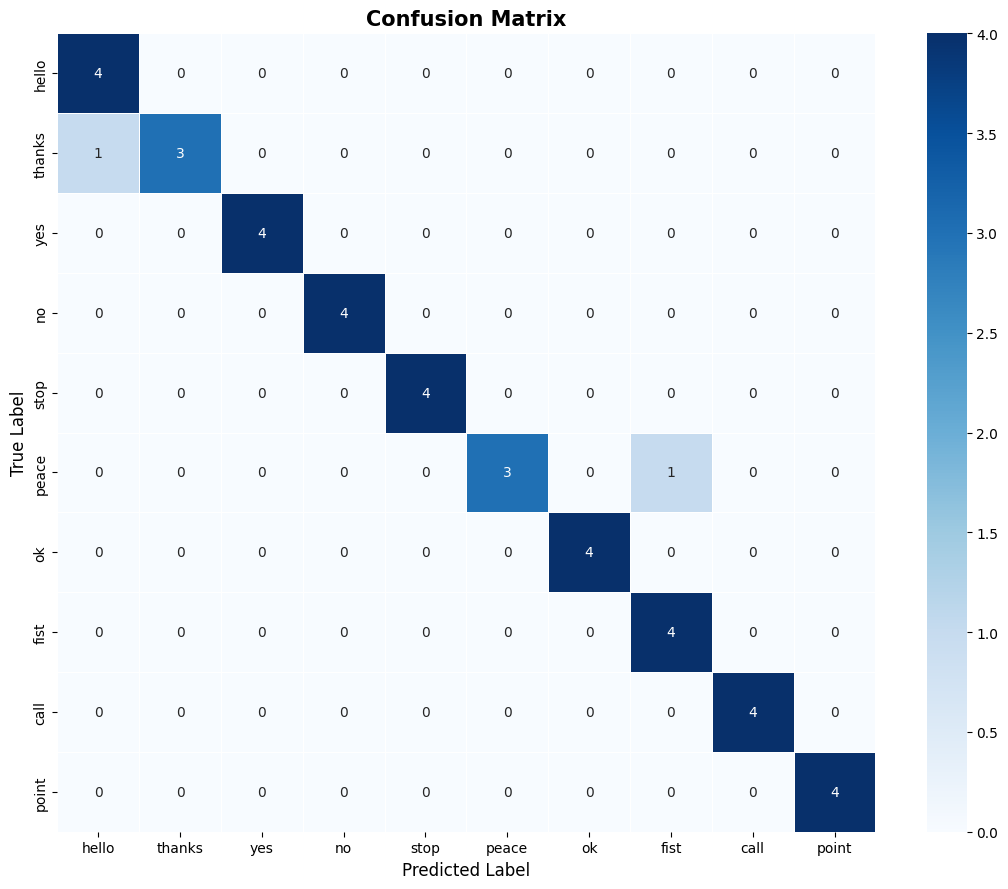


📊 Per-Class Accuracy:
-----------------------------------
  hello       100.0%  ████████████████████
  thanks       75.0%  ███████████████
  yes         100.0%  ████████████████████
  no          100.0%  ████████████████████
  stop        100.0%  ████████████████████
  peace        75.0%  ███████████████
  ok          100.0%  ████████████████████
  fist        100.0%  ████████████████████
  call        100.0%  ████████████████████
  point       100.0%  ████████████████████

📋 Full Classification Report:
              precision    recall  f1-score   support

       hello       0.80      1.00      0.89         4
      thanks       1.00      0.75      0.86         4
         yes       1.00      1.00      1.00         4
          no       1.00      1.00      1.00         4
        stop       1.00      1.00      1.00         4
       peace       1.00      0.75      0.86         4
          ok       1.00      1.00      1.00         4
        fist       0.80      1.00      0.89         4
   

In [12]:
best_model = tf.keras.models.load_model("best_model.keras")

loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy : {accuracy*100:.2f}%")
print(f"✅ Test Loss     : {loss:.4f}")

y_pred = best_model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=actions, yticklabels=actions,
            cmap='Blues', linewidths=0.5)
plt.title('Confusion Matrix', fontsize=15, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n📊 Per-Class Accuracy:")
print("-" * 35)
for i, action in enumerate(actions):
    mask = y_true == i
    if mask.sum() > 0:
        acc = (y_pred_classes[mask] == i).mean() * 100
        bar = "█" * int(acc / 5)
        print(f"  {action:<10} {acc:>6.1f}%  {bar}")

print("\n📋 Full Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=actions))

In [13]:
# Save weights
best_model.save_weights("model_improved.weights.h5")
print("✅ Weights saved")

# Download all files needed for predict.py
from google.colab import files
files.download("best_model.keras")
files.download("model_improved.weights.h5")
files.download("scaler.pkl")   # ← CRITICAL for predict.py accuracy

print("✅ All files downloaded")
print("\n📦 Put these in your local model/ folder:")
print("   model/best_model.keras")
print("   model/model_improved.weights.h5")
print("   model/scaler.pkl   ← don't forget this!")

✅ Weights saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded

📦 Put these in your local model/ folder:
   model/best_model.keras
   model/model_improved.weights.h5
   model/scaler.pkl   ← don't forget this!
